c:\Users\shash\Desktop\SamsungInnovationCampus-AI-ML\SamsungInnovationCampus-AI-ML\.venv\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\shash\Desktop\SamsungInnovationCampus-AI-ML\SamsungInnovationCampus-AI-ML\.venv\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\shash\Desktop\SamsungInnovationCampus-AI-ML\SamsungInnovationCampus-AI-ML\.venv\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info =

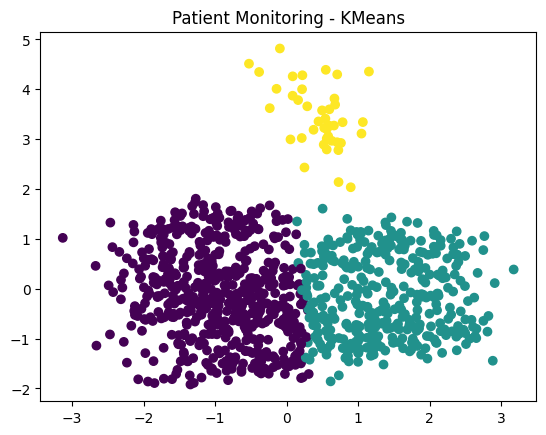

In [1]:
# =============================================
# PROJECT 1: PATIENT MONITORING CLUSTERING
# =============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv("patient_monitoring.csv")

# Preprocess
df = df.select_dtypes(include=[np.number]).dropna()
scaler = StandardScaler()
X = scaler.fit_transform(df)

# PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# K-Means
kmeans = KMeans(n_clusters=3)
labels_k = kmeans.fit_predict(X)

# Hierarchical
hc = AgglomerativeClustering(n_clusters=3)
labels_h = hc.fit_predict(X)

# DBSCAN
db = DBSCAN(eps=0.5, min_samples=5)
labels_d = db.fit_predict(X)

# Plot KMeans
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_k)
plt.title("Patient Monitoring - KMeans")
plt.show()

c:\Users\shash\Desktop\SamsungInnovationCampus-AI-ML\SamsungInnovationCampus-AI-ML\.venv\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


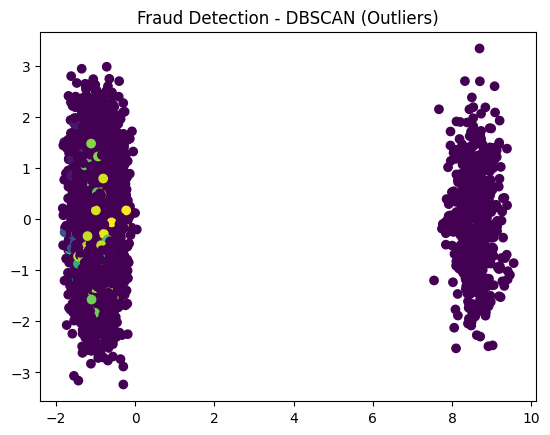

In [2]:
# =============================================
# PROJECT 2: FRAUD DETECTION CLUSTERING
# =============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv("complex_fraud_dataset.csv")

# Preprocess
df = df.select_dtypes(include=[np.number]).dropna()
scaler = StandardScaler()
X = scaler.fit_transform(df)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Models
kmeans = KMeans(n_clusters=4)
labels_k = kmeans.fit_predict(X)

hc = AgglomerativeClustering(n_clusters=4)
labels_h = hc.fit_predict(X)

db = DBSCAN(eps=0.7, min_samples=10)
labels_d = db.fit_predict(X)

# Plot DBSCAN (best for anomaly)
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_d)
plt.title("Fraud Detection - DBSCAN (Outliers)")
plt.show()

c:\Users\shash\Desktop\SamsungInnovationCampus-AI-ML\SamsungInnovationCampus-AI-ML\.venv\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\shash\Desktop\SamsungInnovationCampus-AI-ML\SamsungInnovationCampus-AI-ML\.venv\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "C:\Users\shash\AppData\Local\Programs\Python\Python38\lib\subprocess.py", line 489, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Users\shash\AppData\Local\Programs\Python\Python38\lib\subprocess.py", line 854, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  Fil

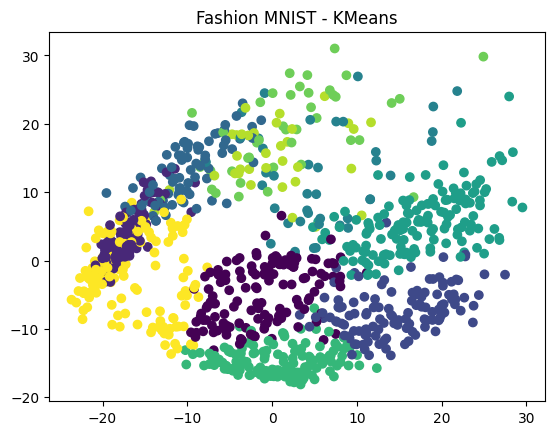

In [1]:
# =============================================
# PROJECT 3: FASHION MNIST CLUSTERING
# =============================================

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

# Load dataset
(X_train, y_train), _ = fashion_mnist.load_data()

# Take only 5000 samples (or even 2000 if slow)
X = X_train[:5000].reshape(5000, -1)

# Normalize
scaler = StandardScaler()
X = scaler.fit_transform(X)

# PCA (important for high-dim data)
pca = PCA(n_components=50)
X_reduced = pca.fit_transform(X)

# Clustering
kmeans = KMeans(n_clusters=10, n_init=10)
labels_k = kmeans.fit_predict(X_reduced)

# Use only 2000 samples for hierarchical
hc = AgglomerativeClustering(n_clusters=10)
labels_h = hc.fit_predict(X_reduced[:2000])

db = DBSCAN(eps=2.5, min_samples=10)
labels_d = db.fit_predict(X_reduced)

# Visualization (first 1000 points)
plt.scatter(X_reduced[:1000,0], X_reduced[:1000,1], c=labels_k[:1000])
plt.title("Fashion MNIST - KMeans")
plt.show()

# =============================================
# END OF ALL 3 PROJECTS
# =============================================


In [ ]:
import matplotlib.pyplot as plt

# Function to show images from a cluster
def show_cluster_images(cluster_id, images, labels, title, n=10):
    idx = np.where(labels == cluster_id)[0][:n]  # get n images
    cluster_images = images[idx]

    plt.figure(figsize=(10, 2))
    for i in range(len(cluster_images)):
        plt.subplot(1, n, i+1)
        plt.imshow(cluster_images[i], cmap='gray')
        plt.axis('off')
    plt.suptitle(f"{title} - Cluster {cluster_id}")
    plt.show()